# Importy

In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import string

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from math import sqrt 

# EDA

In [49]:
# Wczytaj dane
X = pd.read_csv("../Dane/latin_data.csv", header=None)
y = pd.read_csv("../Dane/latin_label.csv", header=None)

X = np.array(X, dtype=np.float32)
y = np.array(y).ravel()

In [50]:
print("Kształt X:", X.shape) 
print("Kształt y:", y.shape)
print("Przykładowe etykiety:", y[:5])


Kształt X: (12822, 784)
Kształt y: (12822,)
Przykładowe etykiety: [0 0 0 0 0]


Jeden obrazek składa się z 784 pikseli oraz są kwadratowe tzn. obrazy są rozmiarów 28 x 28.

In [51]:
img_size = 28

Potrzebna lista liter, żeby etykiety nie były cyframi, tylko bardziej opisowe

In [52]:
letters = np.array(list(string.ascii_uppercase))
y_letters = letters[y]

In [53]:
unique, counts = np.unique(y, return_counts=True)
unique_letters = letters[unique]
for u, c in zip(unique_letters, counts):
    print(f"Etykieta {u}: {c} próbek")


Etykieta A: 493 próbek
Etykieta B: 496 próbek
Etykieta C: 508 próbek
Etykieta D: 461 próbek
Etykieta E: 500 próbek
Etykieta F: 482 próbek
Etykieta G: 509 próbek
Etykieta H: 509 próbek
Etykieta I: 476 próbek
Etykieta J: 458 próbek
Etykieta K: 460 próbek
Etykieta L: 523 próbek
Etykieta M: 547 próbek
Etykieta N: 521 próbek
Etykieta O: 465 próbek
Etykieta P: 526 próbek
Etykieta Q: 484 próbek
Etykieta R: 470 próbek
Etykieta S: 519 próbek
Etykieta T: 477 próbek
Etykieta U: 475 próbek
Etykieta V: 480 próbek
Etykieta W: 465 próbek
Etykieta X: 490 próbek
Etykieta Y: 545 próbek
Etykieta Z: 483 próbek


Posiadamy zbiór 26 liter łacińskich.

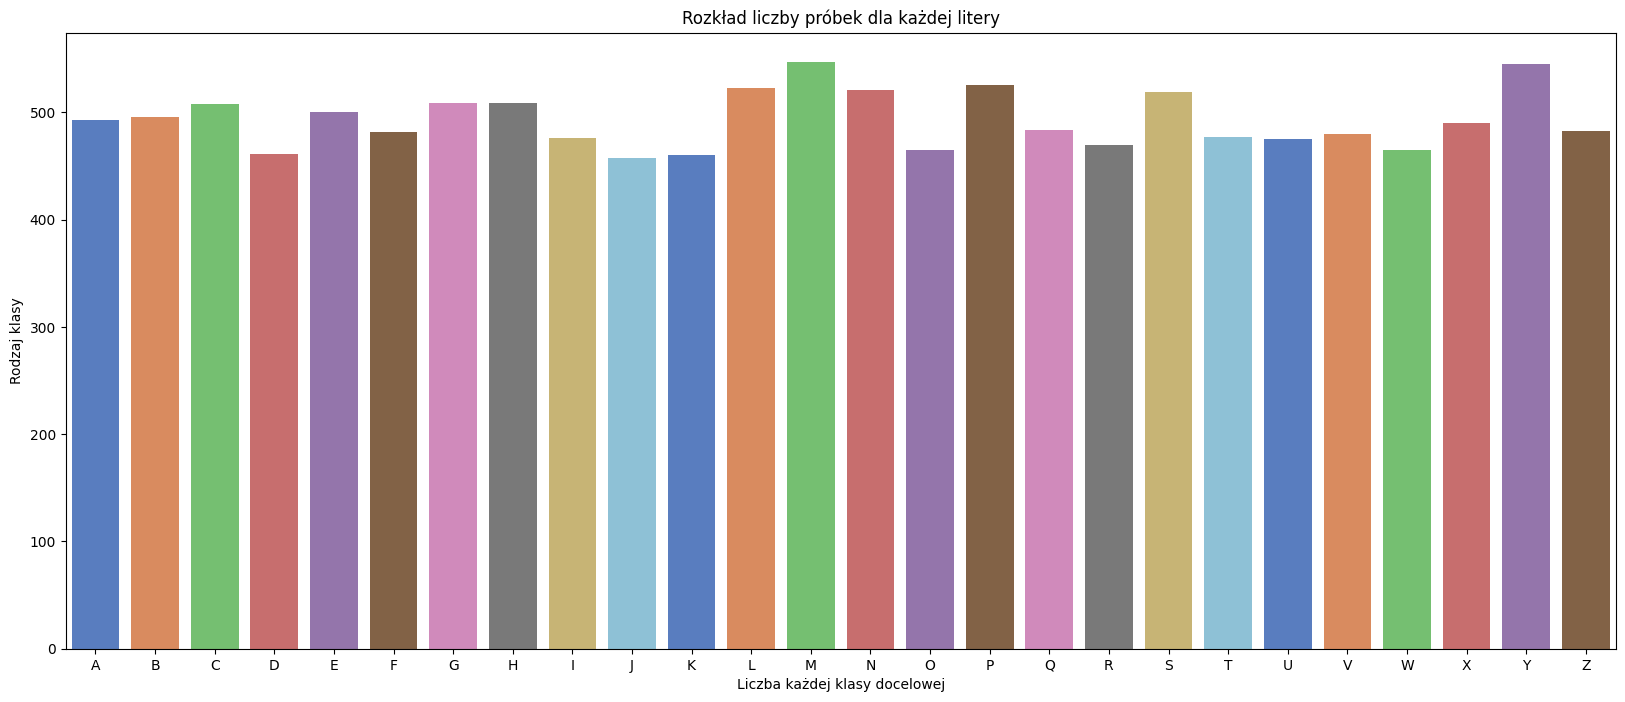

In [54]:
plt.figure(figsize=(20, 8))
sns.countplot(x=y_letters, palette='muted', hue=y)
plt.xlabel('Liczba każdej klasy docelowej')
plt.ylabel("Rodzaj klasy")
plt.title('Rozkład liczby próbek dla każdej litery')
plt.legend().set_visible(False)
plt.show()

Sprawdźmy czy wartości pikseli w obrazach są znormalizowane.

Min piksel: 0.0
Max piksel: 1.0


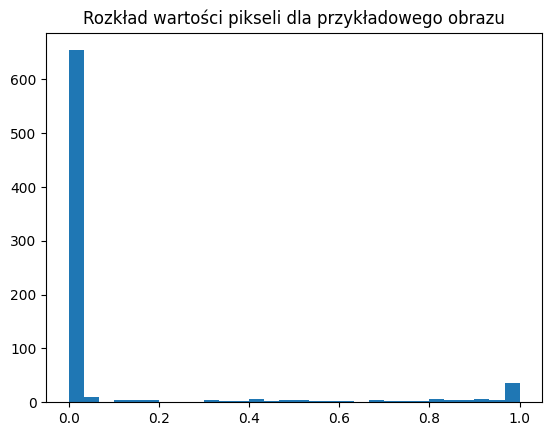

In [55]:
print("Min piksel:", X.min())
print("Max piksel:", X.max())

plt.hist(X[0], bins=30)
plt.title("Rozkład wartości pikseli dla przykładowego obrazu")
plt.show()


Są znormalizowane - dobrze 

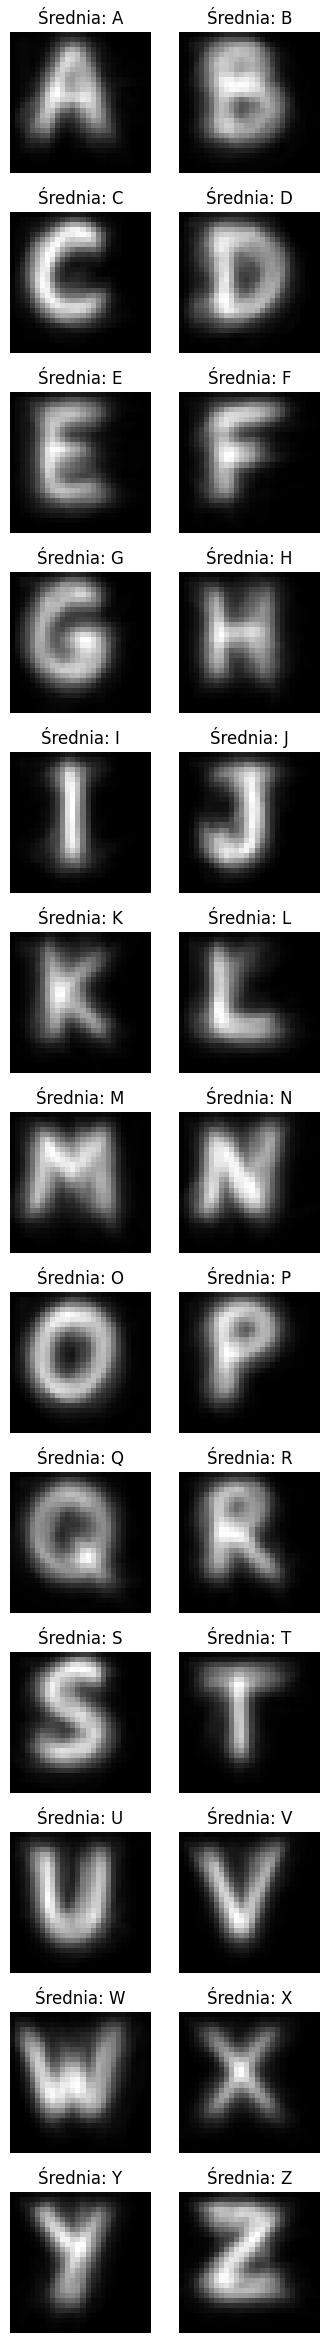

In [63]:
mean_images = []
for label in np.unique(y):
    mean_img = X[y == label].mean(axis=0).reshape(img_size, img_size)
    mean_images.append(mean_img)

plt.figure(figsize=(4, 30))
for i, (label, img) in enumerate(zip(unique_letters, mean_images)):
    plt.subplot(13, 2, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Średnia: {label}")
    plt.axis('off')
plt.show()

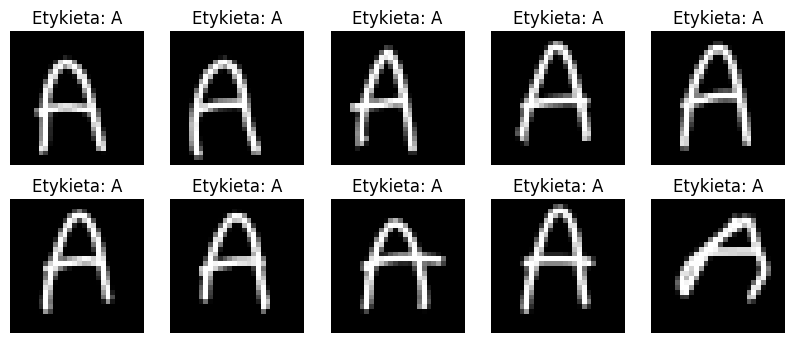

In [61]:
img_size = 28
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i].reshape(img_size, img_size), cmap='gray')
    plt.title(f"Etykieta: {unique_letters[y[i]]}")
    plt.axis('off')
plt.show()